In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [5]:
# Step 1: Load the dataset
data = pd.read_csv('Renewable_Energy_Adoption.csv')

In [6]:
# Step 2: Display the first few rows of the dataset
print("First five rows of the dataset:")
data.head()

First five rows of the dataset:


,carbon_emissions,energy_output,renewability_index,cost_efficiency,adoption
0,181.089042,128.286267,0.642032,0.732568,1
1,382.750007,672.769370,0.084140,2.891096,0
2,306.197880,382.920383,0.161629,2.932858,0
3,259.530469,557.713622,0.898554,3.368435,0
4,104.606524,916.809827,0.606429,3.767411,0


In [7]:
# Step 3: Check for missing values and basic summary statistics
print("\nMissing values in the dataset:")
data.isnull().sum()


Missing values in the dataset:


,0
carbon_emissions,0
energy_output,0
renewability_index,0
cost_efficiency,0
adoption,0


In [8]:
print("\nSummary statistics of the dataset:")
data.describe()


Summary statistics of the dataset:


,carbon_emissions,energy_output,renewability_index,cost_efficiency,adoption
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,214.563260,548.048551,0.517601,2.710170,0.15000
std,104.121294,263.800127,0.293426,1.320535,0.35887
min,51.932741,106.256917,0.005062,0.564771,0.00000
25%,117.620266,317.804074,0.276880,1.623267,0.00000
50%,212.449859,555.062371,0.562555,2.793732,0.00000
75%,305.571092,789.565238,0.752367,3.810999,0.00000
max,395.410428,987.085409,0.990054,4.957273,1.00000


In [9]:
# Check the data info

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   carbon_emissions    100 non-null    float64
 1   energy_output       100 non-null    float64
 2   renewability_index  100 non-null    float64
 3   cost_efficiency     100 non-null    float64
 4   adoption            100 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 4.0 KB


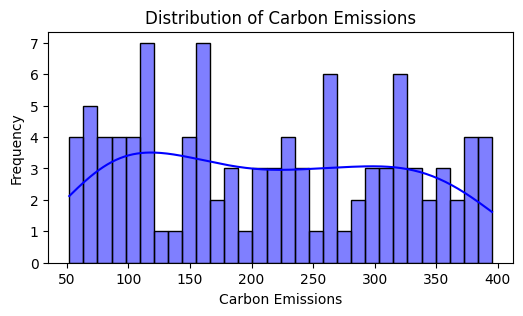

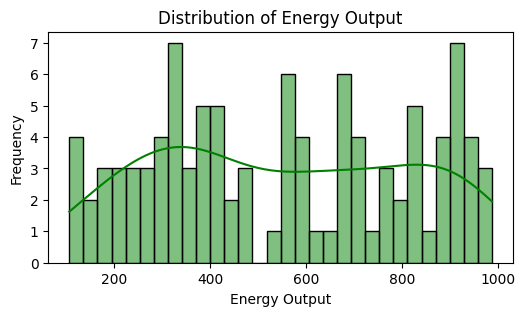

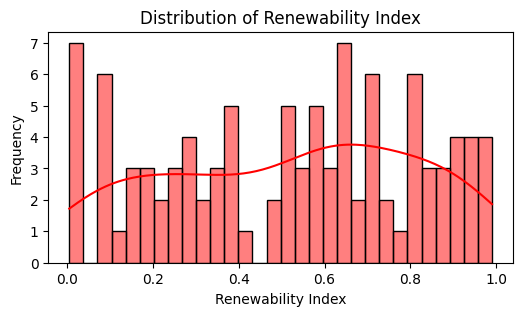

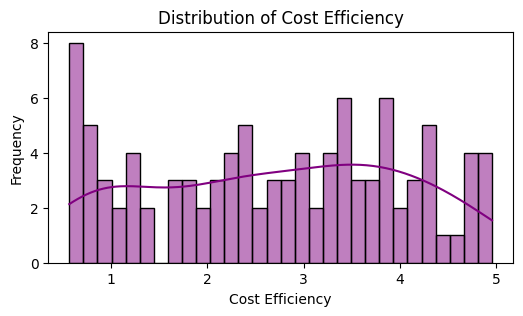

In [10]:
# Step 4: Visualize the distribution of key features
plt.figure(figsize=(6, 3))
sns.histplot(data['carbon_emissions'], kde=True, color='blue', bins=30)
plt.title('Distribution of Carbon Emissions')
plt.xlabel('Carbon Emissions')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 3))
sns.histplot(data['energy_output'], kde=True, color='green', bins=30)
plt.title('Distribution of Energy Output')
plt.xlabel('Energy Output')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 3))
sns.histplot(data['renewability_index'], kde=True, color='red', bins=30)
plt.title('Distribution of Renewability Index')
plt.xlabel('Renewability Index')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(6, 3))
sns.histplot(data['cost_efficiency'], kde=True, color='purple', bins=30)
plt.title('Distribution of Cost Efficiency')
plt.xlabel('Cost Efficiency')
plt.ylabel('Frequency')
plt.show()

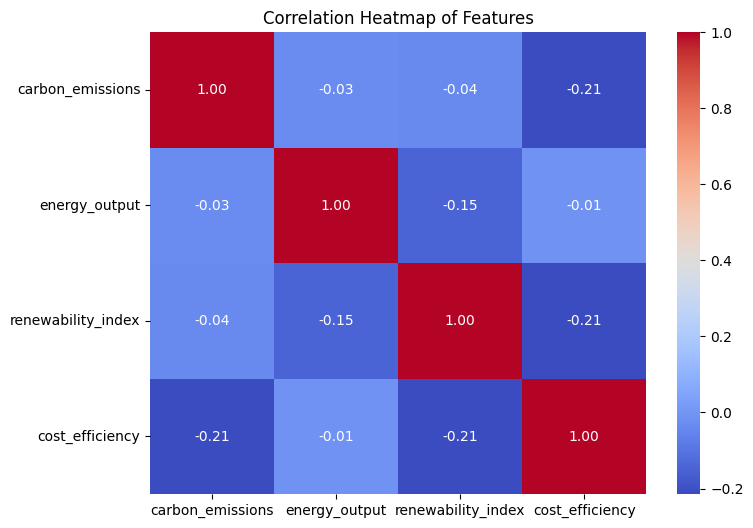

In [11]:
# Step 5: Correlation heatmap to understand relationships between features
correlation_matrix = data[['carbon_emissions', 'energy_output', 'renewability_index', 'cost_efficiency']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

In [12]:
# Scaling the data

scaler = StandardScaler()
scaled_features = scaler.fit_transform(data.drop(columns=['adoption']))

In [13]:
# Step 6: Prepare the data for model training

# Features (X) and Target variable (y)
X = pd.DataFrame(scaled_features, columns=data.columns[:-1])
y = data['adoption']  # Target variable

In [14]:
# Step 7: Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [39]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)  # Limiting max depth to avoid overfitting
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [40]:
# why parameters are not shown in model


In [41]:
# Step 9: Make predictions on the test set
y_pred = model.predict(X_test)

In [42]:
# Step 10: Evaluate the model

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy of the Decision Tree Model:", accuracy)


Accuracy of the Decision Tree Model: 0.85


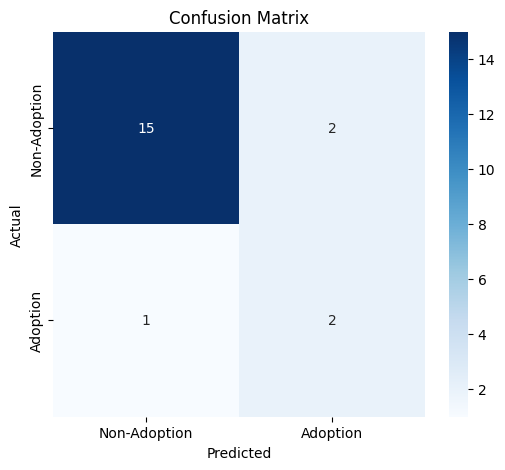

In [43]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Adoption', 'Adoption'],
            yticklabels=['Non-Adoption', 'Adoption'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [44]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Adoption', 'Adoption']))



Classification Report:
              precision    recall  f1-score   support

Non-Adoption       0.94      0.88      0.91        17
    Adoption       0.50      0.67      0.57         3

    accuracy                           0.85        20
   macro avg       0.72      0.77      0.74        20
weighted avg       0.87      0.85      0.86        20



In [45]:
# Step 11: Save the trained model to a file
joblib.dump(model, 'Renewable_Energy_Adoption_model.pkl')
print("\nModel has been saved to 'Renewable_Energy_Adoption_model.pkl'.")


Model has been saved to 'Renewable_Energy_Adoption_model.pkl'.


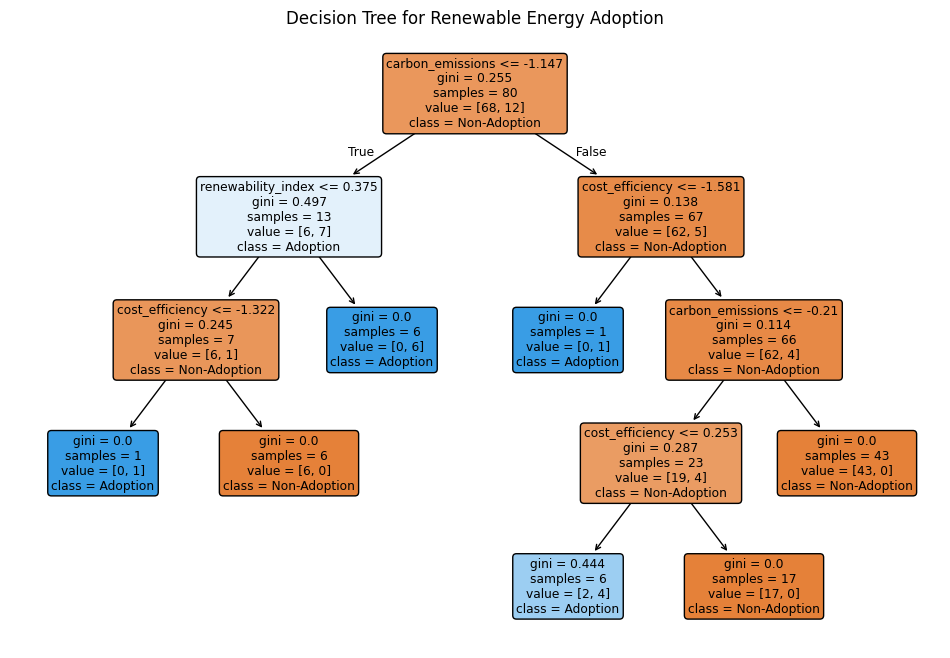

In [46]:
# Step 12: Visualizing the Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=X.columns, class_names=['Non-Adoption', 'Adoption'], filled=True, rounded=True)
plt.title('Decision Tree for Renewable Energy Adoption')
plt.savefig('dt1.png')
plt.show()

## Hyperparameter Tuning

In [47]:
# Import necessary libraries for hyperparameter tuning
from sklearn.model_selection import GridSearchCV


In [48]:
# Step 1: Define the parameter grid for hyperparameter tuning
param_grid = {
    'max_depth': [2, 3, 4, 5, 10, None],  # Depth of the tree
    'min_samples_split': [2, 3, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 3, 5],  # Minimum number of samples required at a leaf node
    'criterion': ['gini', 'entropy'],  # Splitting criterion (Gini impurity or Entropy)
}

In [49]:
# Step 2: Initialize the DecisionTreeClassifier
dtree = DecisionTreeClassifier(random_state=42)


In [50]:
# Step 3: Set up the GridSearchCV
grid_search = GridSearchCV(estimator=dtree, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

In [51]:
# Step 4: Fit the model using GridSearchCV to find the best parameters
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 10, None],
                         'min_samples_leaf': [1, 2, 3, 5],
                         'min_samples_split': [2, 3, 5, 10]},
             scoring='accuracy', verbose=2)

In [52]:
# Step 5: Print the best parameters and best score
print("\nBest Hyperparameters found by GridSearchCV:")
print(grid_search.best_params_)


Best Hyperparameters found by GridSearchCV:
{'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [53]:
# Step 6: Use the best model from GridSearchCV
best_model = grid_search.best_estimator_

In [54]:
# Step 7: Predict on the test set with the best model
y_pred_best = best_model.predict(X_test)

In [55]:
# Step 8: Evaluate the performance of the tuned model
accuracy_best = accuracy_score(y_test, y_pred_best)
print("\nAccuracy of the best Decision Tree Model:", accuracy_best)


Accuracy of the best Decision Tree Model: 1.0


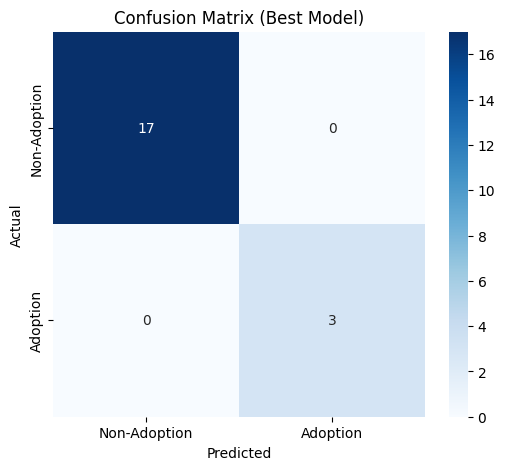

In [56]:
# Confusion Matrix
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Adoption', 'Adoption'],
            yticklabels=['Non-Adoption', 'Adoption'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Best Model)')
plt.show()

In [ ]:
# Classification Report
print("\nClassification Report (Best Model):")
print(classification_report(y_test, y_pred_best, target_names=['Non-Adoption', 'Adoption']))


In [ ]:
# Step 9: Save the best model
joblib.dump(best_model, 'Best_Renewable_Energy_Adoption_model.pkl')
print("\nBest model has been saved to 'Best_Renewable_Energy_Adoption_model.pkl'.")


In [ ]:
# Step 10: Visualize the decision tree of the best model
plt.figure(figsize=(12, 8))
plot_tree(best_model, feature_names=X.columns, class_names=['Non-Adoption', 'Adoption'], filled=True, rounded=True)
plt.title('Best Decision Tree for Renewable Energy Adoption')
plt.savefig('best_dt.png')
plt.show()